# 이상지질혈증 예측 - XGBoost Threshold 조정

- 타겟: `이상지질혈증유병` (0: 없음 / 1: 있음)
- 모델: XGBoost (베이스라인과 동일 파라미터)
- 데이터: x1_preprocessed.csv
- 개선 포인트: OOF proba 기반 최적 threshold 탐색
- 목표: **Recall ≥ 0.80 유지하면서 F1 최대화**
- 검증: Stratified 5-Fold CV

In [ ]:
import os
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
matplotlib.rcParams["font.family"] = "DejaVu Sans"


# ── 경로 설정 ──────────────────────────────────────────────
INPUT_PATH = "/Users/Jiyeon/Desktop/final_project/ML/data/x1_preprocessed.csv"
NPY_DIR = "/Users/Jiyeon/Desktop/final_project/ML/outputs/oof"
RANDOM_STATE = 42

## 1. 데이터 로드

In [2]:
df = pd.read_csv(INPUT_PATH)
print(f"로드 완료 | shape: {df.shape}")

로드 완료 | shape: (6033, 32)


## 2. 피처 / 타겟 분리

In [3]:
TARGET = "이상지질혈증유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병", "비만단계"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)

neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos
print(f"샘플 수: {len(y)}  |  정상: {neg}  |  이상지질혈증: {pos}")
print(f"불균형 비율: {ratio:.4f}  |  scale_pos_weight: {ratio:.4f}")

샘플 수: 6033  |  정상: 4475  |  이상지질혈증: 1558
불균형 비율: 2.8723  |  scale_pos_weight: 2.8723


## 3. Stratified 5-Fold CV — OOF proba 수집

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
fold_scores = []

print("=" * 65)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=ratio,
        eval_metric="auc",
        early_stopping_rounds=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba

    pred = (proba >= 0.5).astype(int)
    cm_f = confusion_matrix(y_val, pred)
    fold_scores.append(
        {
            "fold": fold,
            "auc": roc_auc_score(y_val, proba),
            "f1": f1_score(y_val, pred),
            "recall": recall_score(y_val, pred),
            "precision": precision_score(y_val, pred),
            "fp": int(cm_f[0, 1]),
            "best_iter": model.best_iteration,
        }
    )
    print(
        f"  Fold {fold} | AUC: {fold_scores[-1]['auc']:.4f} | "
        f"Recall: {fold_scores[-1]['recall']:.4f} | "
        f"F1: {fold_scores[-1]['f1']:.4f} | "
        f"best_iter: {model.best_iteration}"
    )

scores_df = pd.DataFrame(fold_scores)
print("=" * 65)
print(
    f"  평균   | AUC: {scores_df.auc.mean():.4f}±{scores_df.auc.std():.4f} "
    f"| Recall: {scores_df.recall.mean():.4f}±{scores_df.recall.std():.4f} "
    f"| F1: {scores_df.f1.mean():.4f}±{scores_df.f1.std():.4f}"
)

  Fold 1 | AUC: 0.7904 | Recall: 0.8077 | F1: 0.5484 | best_iter: 35
  Fold 2 | AUC: 0.7784 | Recall: 0.7660 | F1: 0.5469 | best_iter: 54
  Fold 3 | AUC: 0.7910 | Recall: 0.7853 | F1: 0.5619 | best_iter: 140
  Fold 4 | AUC: 0.8068 | Recall: 0.8328 | F1: 0.5618 | best_iter: 36
  Fold 5 | AUC: 0.7881 | Recall: 0.7846 | F1: 0.5577 | best_iter: 43
  평균   | AUC: 0.7909±0.0102 | Recall: 0.7953±0.0257 | F1: 0.5554±0.0072


## OOF proba 저장 (.npy)

In [5]:
os.makedirs(NPY_DIR, exist_ok=True)
npy_path = os.path.join(NPY_DIR, "oof_proba_HL_xgboost_threshold.npy")
oof_array = np.stack([oof_proba, y.values], axis=1)  # col0: proba, col1: y_true
np.save(npy_path, oof_array)
print(f"저장 완료 → {npy_path}")
print(f"shape: {oof_array.shape}  (col0: oof_proba, col1: y_true)")
loaded = np.load(npy_path)
print(f"로드 확인: shape={loaded.shape}, 일치={np.allclose(oof_array, loaded)}")

저장 완료 → /Users/Jiyeon/Desktop/final_project/ML/outputs/oof/oof_proba_HL_xgboost_threshold.npy
shape: (6033, 2)  (col0: oof_proba, col1: y_true)
로드 확인: shape=(6033, 2), 일치=True


## 4. Threshold 탐색 (0.30 ~ 0.60)

In [6]:
thresholds = np.arange(0.30, 0.65, 0.05).round(2)
thr_results = []

print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>8} {'FP':>6} {'FN':>6}")
print("-" * 55)
for t in thresholds:
    pred_t = (oof_proba >= t).astype(int)
    cm_t = confusion_matrix(y, pred_t)
    rec = recall_score(y, pred_t)
    prec = precision_score(y, pred_t)
    f1 = f1_score(y, pred_t)
    thr_results.append(
        {"threshold": t, "recall": rec, "precision": prec, "f1": f1, "fp": int(cm_t[0, 1]), "fn": int(cm_t[1, 0])}
    )
    marker = "  ◀ baseline" if t == 0.50 else ""
    print(f"{t:>10.2f} {rec:>8.4f} {prec:>10.4f} {f1:>8.4f} {cm_t[0, 1]:>6} {cm_t[1, 0]:>6}{marker}")

thr_df = pd.DataFrame(thr_results)

# Recall >= 0.80 조건 하 F1 최고
cond = thr_df[thr_df.recall >= 0.80]
best_row = cond.loc[cond.f1.idxmax()] if len(cond) > 0 else thr_df.loc[thr_df.f1.idxmax()]
BEST_THRESHOLD = best_row.threshold
print(
    f"\n★ Recall≥0.80 조건 하 F1 최고: threshold={BEST_THRESHOLD:.2f} | "
    f"Recall={best_row.recall:.4f} | F1={best_row.f1:.4f} | FP={best_row.fp}"
)

 Threshold   Recall  Precision       F1     FP     FN
-------------------------------------------------------
      0.30   0.9332     0.3833   0.5434   2339    104
      0.35   0.9114     0.3913   0.5475   2209    138
      0.40   0.8838     0.4022   0.5528   2047    181
      0.45   0.8427     0.4129   0.5542   1867    245
      0.50   0.7953     0.4267   0.5554   1665    319  ◀ baseline
      0.55   0.7182     0.4556   0.5575   1337    439
      0.60   0.6085     0.4902   0.5430    986    610

★ Recall≥0.80 조건 하 F1 최고: threshold=0.45 | Recall=0.8427 | F1=0.5542 | FP=1867.0


## 5. Threshold별 지표 시각화

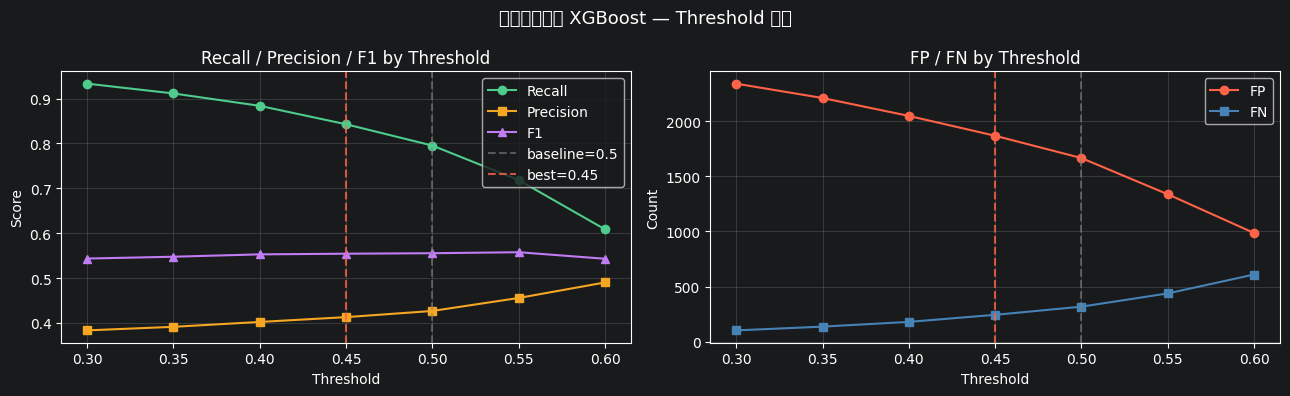

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(thr_df.threshold, thr_df.recall, marker="o", label="Recall", color="#4ecb8d")
axes[0].plot(thr_df.threshold, thr_df.precision, marker="s", label="Precision", color="#f5a623")
axes[0].plot(thr_df.threshold, thr_df.f1, marker="^", label="F1", color="#bf7cf5")
axes[0].axvline(0.5, color="gray", linestyle="--", alpha=0.6, label="baseline=0.5")
axes[0].axvline(BEST_THRESHOLD, color="tomato", linestyle="--", alpha=0.8, label=f"best={BEST_THRESHOLD:.2f}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Recall / Precision / F1 by Threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(thr_df.threshold, thr_df.fp, marker="o", color="tomato", label="FP")
axes[1].plot(thr_df.threshold, thr_df.fn, marker="s", color="steelblue", label="FN")
axes[1].axvline(0.5, color="gray", linestyle="--", alpha=0.6)
axes[1].axvline(BEST_THRESHOLD, color="tomato", linestyle="--", alpha=0.8)
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Count")
axes[1].set_title("FP / FN by Threshold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("이상지질혈증 XGBoost — Threshold 분석", fontsize=13)
plt.tight_layout()
plt.show()

## 6. 최적 Threshold 확정 & baseline 비교

In [8]:
pred_base = (oof_proba >= 0.50).astype(int)
pred_best = (oof_proba >= BEST_THRESHOLD).astype(int)
cm_base = confusion_matrix(y, pred_base)
cm_best = confusion_matrix(y, pred_best)

print("=" * 55)
print(f"  {'지표':<12}  {'baseline (0.50)':>16}  {f'best ({BEST_THRESHOLD:.2f})':>10}  변화")
print("=" * 55)
for name, fn in [("Recall", recall_score), ("Precision", precision_score), ("F1-score", f1_score), ("AUC-ROC", None)]:
    if fn:
        v_base = fn(y, pred_base)
        v_best = fn(y, pred_best)
    else:
        v_base = v_best = roc_auc_score(y, oof_proba)
    d = v_best - v_base
    arrow = "▲" if d > 0 else ("▼" if d < 0 else "─")
    print(f"  {name:<12}  {v_base:>16.4f}  {v_best:>10.4f}  {arrow} {abs(d):.4f}")
print(
    f"  {'FP':<12}  {cm_base[0, 1]:>16}  {cm_best[0, 1]:>10}  {'▼' if cm_best[0, 1] < cm_base[0, 1] else '▲'} {abs(cm_best[0, 1] - cm_base[0, 1])}"
)
print(
    f"  {'FN':<12}  {cm_base[1, 0]:>16}  {cm_best[1, 0]:>10}  {'▼' if cm_best[1, 0] < cm_base[1, 0] else '▲'} {abs(cm_best[1, 0] - cm_base[1, 0])}"
)
print("=" * 55)

print(f"\n[분류 리포트 — threshold {BEST_THRESHOLD:.2f}]")
print(classification_report(y, pred_best, target_names=["정상(0)", "이상지질혈증(1)"]))

  지표             baseline (0.50)  best (0.45)  변화
  Recall                  0.7953      0.8427  ▲ 0.0475
  Precision               0.4267      0.4129  ▼ 0.0138
  F1-score                0.5554      0.5542  ▼ 0.0011
  AUC-ROC                 0.7879      0.7879  ─ 0.0000
  FP                        1665        1867  ▲ 202
  FN                         319         245  ▼ 74

[분류 리포트 — threshold 0.45]
              precision    recall  f1-score   support

       정상(0)       0.91      0.58      0.71      4475
   이상지질혈증(1)       0.41      0.84      0.55      1558

    accuracy                           0.65      6033
   macro avg       0.66      0.71      0.63      6033
weighted avg       0.78      0.65      0.67      6033



## 7. Confusion Matrix 비교

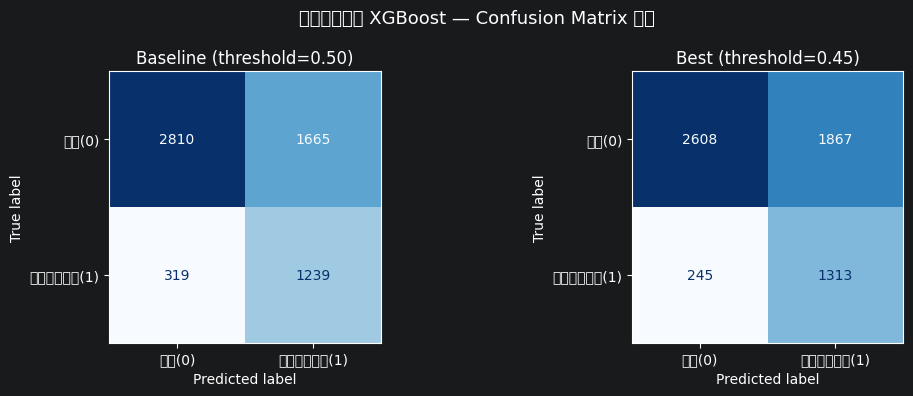

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title in zip(
    axes, [cm_base, cm_best], ["Baseline (threshold=0.50)", f"Best (threshold={BEST_THRESHOLD:.2f})"]
):
    ConfusionMatrixDisplay(cm, display_labels=["정상(0)", "이상지질혈증(1)"]).plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title)
plt.suptitle("이상지질혈증 XGBoost — Confusion Matrix 비교", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Precision-Recall 커브

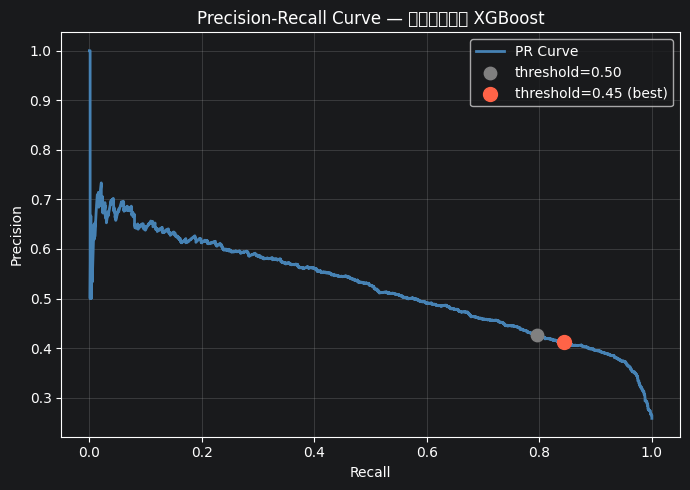

In [10]:
prec_curve, rec_curve, thr_curve = precision_recall_curve(y, oof_proba)

plt.figure(figsize=(7, 5))
plt.plot(rec_curve, prec_curve, color="steelblue", lw=2, label="PR Curve")
idx_base = np.argmin(np.abs(thr_curve - 0.50))
plt.scatter(rec_curve[idx_base], prec_curve[idx_base], s=80, color="gray", zorder=5, label="threshold=0.50")
idx_best = np.argmin(np.abs(thr_curve - BEST_THRESHOLD))
plt.scatter(
    rec_curve[idx_best],
    prec_curve[idx_best],
    s=100,
    color="tomato",
    zorder=5,
    label=f"threshold={BEST_THRESHOLD:.2f} (best)",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — 이상지질혈증 XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. DB 로그 저장

In [11]:
import sys

sys.path.insert(0, "/Users/Jiyeon/Desktop/final_project/ML")
from model_logger import ModelLogger

logger = ModelLogger("/Users/Jiyeon/Desktop/final_project/ML/model_result.db")

pred_final = (oof_proba >= BEST_THRESHOLD).astype(int)
cm_final = confusion_matrix(y, pred_final)

booster = model.get_booster()
gain = pd.Series(booster.get_score(importance_type="gain"))
gain = gain.reindex(X.columns, fill_value=0).sort_values(ascending=False)

run_id = logger.log_run(
    target_var="이상지질혈증",
    model_name="XGBoost",
    stage=f"threshold_{BEST_THRESHOLD:.2f}",
    hyperparams={
        "learning_rate": 0.05,
        "max_depth": 6,
        "n_estimators": 500,
        "class_weight": {0: 1.0, 1: round(ratio, 4)},
        "eval_metric": "auc",
        "early_stopping_rounds": 50,
    },
    data_info={
        "feature_count": X.shape[1],
        "train_test_split": "5-Fold CV",
        "scaling_method": "None",
    },
    oof_metrics={
        "accuracy": float((pred_final == y).mean()),
        "recall": recall_score(y, pred_final),
        "precision": precision_score(y, pred_final),
        "f1_score": f1_score(y, pred_final),
        "auc_roc": roc_auc_score(y, oof_proba),
        "cm": cm_final.tolist(),
    },
    fold_scores=scores_df.to_dict("records"),
    threshold_results=thr_df.to_dict("records"),
    top_features=gain.head(15).to_dict(),
    note=f"Threshold {BEST_THRESHOLD:.2f} 조정. Recall>=0.80 조건 하 F1 최고점.",
)

print(f"저장 완료 → run_id: {run_id}")
print()
print("[전체 실험 목록]")
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=8 | 이상지질혈증 XGBoost (threshold_0.45)
저장 완료 → run_id: 8

[전체 실험 목록]
 run_id          created_at target_var model_name          stage  auc_roc   recall  precision  f1_score  accuracy
      8 2026-05-15 18:06:03     이상지질혈증    XGBoost threshold_0.45 0.787916 0.842747   0.412893  0.554242  0.649925
      7 2026-05-15 17:34:49         당뇨    XGBoost    optuna_shap 0.790561 0.839704   0.246829  0.381513  0.634013
      6 2026-05-15 17:24:13         당뇨    XGBoost         optuna 0.804071 0.831073   0.266403  0.403472  0.669650
      5 2026-05-15 17:02:27         당뇨    XGBoost threshold_0.45 0.783068 0.816276   0.253446  0.386795  0.652080
      4 2026-05-15 16:25:48        고혈압    XGBoost    optuna_shap 0.859112 0.826190   0.542399  0.654871  0.757500
      3 2026-05-15 16:22:42        고혈압    XGBoost    optuna_shap 0.859112 0.826190   0.542399  0.654871  0.757500
      2 2026-05-15 15:55:46        고혈압    XGBoost         optuna 0.859112 0.826190   0.542399  0.654871  0.